In [1]:
import pandas as pd
import numpy as np
import os
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"


from pathlib import Path
import pickle

#### graphical
import matplotlib.pyplot as plt
import corner


import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
import arviz as az
import jax

from numpyro.infer import MCMC, NUTS, Predictive

from emulator import Emulator
from utils import norm, unnorm 

from numpyro.handlers import reparam

from WMSE import WMSE, WMSE_metric

import tensorflow as tf
os.environ["CUDA_VISIBLE_DEVICES"]="0"
jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()

from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)
jax.process_index(backend=None)

2025-09-29 16:06:29.307036: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759158389.343340   32982 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759158389.355075   32982 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/tmp/ipykernel_32982/4045359720.py:36: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  print(xla_bridge.get_backend().platform)


cpu


0

In [2]:
def sample_beta(param_name, loc, scale, alpha = 2, beta = 2):

    beta_samp = numpyro.sample(f'{param_name}_beta', dist.Beta(alpha, beta))

    return numpyro.deterministic(param_name, loc + scale*beta_samp)

def lnsigmoid(x, k, mini, spread):
    s = k*(x - mini)/spread
    y = (1 + jnp.exp(-s))
    return -1*jnp.log(y)

In [3]:
seed = 42

df_full = pd.read_hdf('../grids/Chiara-dnufit.hdf5', key='df') ## edit for your grid!!

df_full['logLPhot'] = np.log10(df_full['LPhot'])

df_full['lognumax'] = np.log10(df_full['numax']*3090)

df_full['logdnufit'] = np.log10(df_full['dnufit']*135)

df_full['logAge'] = np.log10(df_full['age'])

#### define inputs
inputs = ['massini', 'zini', 'yini', 'alphaMLT', 'logAge', 'eta', 'alphaFe']

#### define outputs
classical_outputs = ['FeH', 'logLPhot', 'Teff']
astero_outputs = ['lognumax', 'logdnufit'] 

outputs = classical_outputs+astero_outputs

df = df_full[inputs+outputs]

df_norm = (df - df.min())/(df.max() - df.min())
df_train = df.sample(frac=0.95, random_state=seed)
df_test = df.drop(df_train.index)
df_small = df_full.sample(1000)

In [4]:
normconsts = np.load('../grids/Chiara-normconsts-logAge.npy', allow_pickle = True).item()

modelpath = '/home/hatte/M4/models'

n_dense_layers = 6

dense_layer_units = 128

Nepochs = 100000

learning_rate = 0.0001

model_name = 'logAge-logLPhot-lognumax-logdnufit-exponent-6e-6-Adam'

loss_func = 'WMSE'

checkpoint_dir = f'{modelpath}/long-runs/checkpoint/chk-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.model.keras'

emulator_kwargs =  {'model_name':model_name, 'n_dense_layers':n_dense_layers, 'dense_layer_units':dense_layer_units, 'Nepochs':Nepochs, 'lrate':learning_rate, \
        'loss':loss_func, 'model_dir':'../models',  'inputs': ['massini', 'zini', 'yini', 'alphaMLT', 'logAge', 'eta', 'alphaFe'], 'outputs':['FeH', 'logLPhot', 'Teff', 'lognumax', 'logdnuSer'],\
        'normconsts':normconsts, 'checkpoint_dir':checkpoint_dir, 'custom_objects':{'WMSE':WMSE_metric}}

model_outputs = Emulator(emulator_kwargs, normalised = False)
model= tf.keras.models.load_model(checkpoint_dir, custom_objects = {'WMSE':WMSE_metric})

I0000 00:00:1759158394.567531   32982 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17665 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:41:00.0, compute capability: 8.6


# Tailo's data

In [5]:
T22 = pd.read_csv('../data/T22M08.csv')
T22 = T22.drop([13, 15])

remove = []
imin = 0 
imax = 25

T22 = T22.reset_index()[imin:imax]
#Think its index 4 throwing it off

IDs = T22['WID']

numax = T22['numax']
enumax_obs = T22['enumax']
enumax_pred = 0.009*numax
enumax = np.sqrt(enumax_obs**2 + enumax_pred**2)

dnu = T22['dnu']
ednu_obs = T22['ednu']
ednu_pred = 0.007*dnu
ednu = np.sqrt(ednu_obs**2 + ednu_pred**2)


LPhot = T22['LPhot']
eLPhot_obs = T22['eLPhot']
eLPhot_pred = 0.011*LPhot
eLPhot = np.sqrt(eLPhot_obs**2 + eLPhot_pred**2)

FeH = T22['[Fe/HI]']

alphaFe = T22['alphaFe']

Teff = T22['Teff']

num_stars = len(Teff)

obs = {'FeH':FeH.values,  'Teff':Teff.values, 'numax':numax.values, 'dnuSer':dnu.values,'logLPhot':np.log10(LPhot.values), 'LPhot':LPhot.values}
unc = {'Teff':Teff.values, 'numax': enumax.values, 'dnuSer':ednu.values, 'FeH':0.05*np.ones_like(Teff.values), 'logLPhot':eLPhot.values/LPhot.values*1/np.log(10), 'LPhot':eLPhot.values}
unc['Teff'] = 100*np.ones_like(Teff.values)

# Fit a fake cluster - hierarchical on age

In [6]:
#@reparam(config={"age":LocScaleReparam()}) #something about this causes chaos

def shared_2param(uncs,  obs = model_outputs.obs_dict):

    age = sample_beta('age', 9000, 4000, alpha = 10, beta = 10)

    zini = sample_beta('zini', 0.5*0.01756*10**-1.1, 2*0.01756*10**-1.1, alpha = 2, beta = 2) #This is probably far too conservative 

    yini = sample_beta('yini', 0.248, 0.05, alpha = 1.5, beta = 5)

    alphaMLT = sample_beta('alphaMLT', 1.5, 0.8, alpha = 1.5, beta = 1.5)

    eta = sample_beta('eta', 0.0004, 0.29, alpha = 1.5, beta = 1.5)

    alphaFe = sample_beta('alphaFe', 0.31, 0.15, alpha = 5, beta = 5) #Proxy for a normal distribution
    
    with numpyro.plate("star", num_stars):    
   
        tau = sample_beta('tau', 1.0, 0.5, alpha = 2, beta = 2)

        star_age = jnp.stack([age for i in range(num_stars)], axis = 0)

        star_zini = jnp.stack([zini for i in range(num_stars)], axis = 0)
        
        star_yini = jnp.stack([yini for i in range(num_stars)], axis = 0)

        star_aMLT = jnp.stack([alphaMLT for i in range(num_stars)], axis = 0)

        star_eta = jnp.stack([eta for i in range(num_stars)], axis = 0)

        star_aFe = jnp.stack([alphaFe for i in range(num_stars)], axis = 0)

        massini = numpyro.deterministic('massini', tau*jnp.exp(-0.3*jnp.log(star_age) + 2.4)) #I got the values in here from fitting the distribution in the grid and then varying the offset such that its a lower bound (a bit naff, I know)

        numpyro.factor('logfac',lnsigmoid(massini, 10, 0.7, 0.01))

        params = jnp.stack([massini, star_zini, star_yini, star_aMLT, jnp.log10(star_age), star_eta, star_aFe], axis = -1)

        pred = model_outputs(params)

    FeH = numpyro.sample("FeH", dist.StudentT(df = 10, loc = pred[:, 0], scale = uncs['FeH']), obs=obs['FeH'])
    
    LPhot = numpyro.sample("LPhot", dist.StudentT(df = 10, loc = 10**pred[:, 1], scale = uncs['LPhot']), obs=obs['LPhot'])
    
    Teff = numpyro.sample("Teff", dist.StudentT(df = 10, loc = pred[:, 2], scale = uncs['Teff']), obs=obs['Teff'])

    dnu = numpyro.sample("dnuSer", dist.StudentT(df = 10, loc = 10**(pred[:, 4])/1.0109, scale = uncs['dnuSer']), obs=obs['dnuSer'])

 





In [105]:
num_warmup, num_samples = 4000,4000
#10000, 8000 works with stars 6, 16
num_chains = 1

sampler = NUTS(shared_2param, target_accept_prob=0.8, find_heuristic_step_size=True, init_strategy=numpyro.infer.init_to_sample) #May be worth trying init_to_sample

mcmc = MCMC(sampler, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)

In [114]:
rng_key = jax.random.PRNGKey(0)

rng_key, rng_key_ = jax.random.split(rng_key)

num_prior_samples = 1000

prior_predictive = Predictive(shared_2param, num_samples=num_prior_samples,)

prior = prior_predictive(rng_key_, \
                         uncs=unc, )

coords = {"star": np.arange(num_stars)}
dims = {}
for key, value in prior.items():
    dims[key] = dim = []
    if value.ndim == 1:
        continue
    if value.shape[-1] == num_stars:
        dim.append("star")

data = az.from_numpyro(prior=prior, coords=coords, dims=dims)
data


Inference data with groups:
	> prior

# Prior versus grid

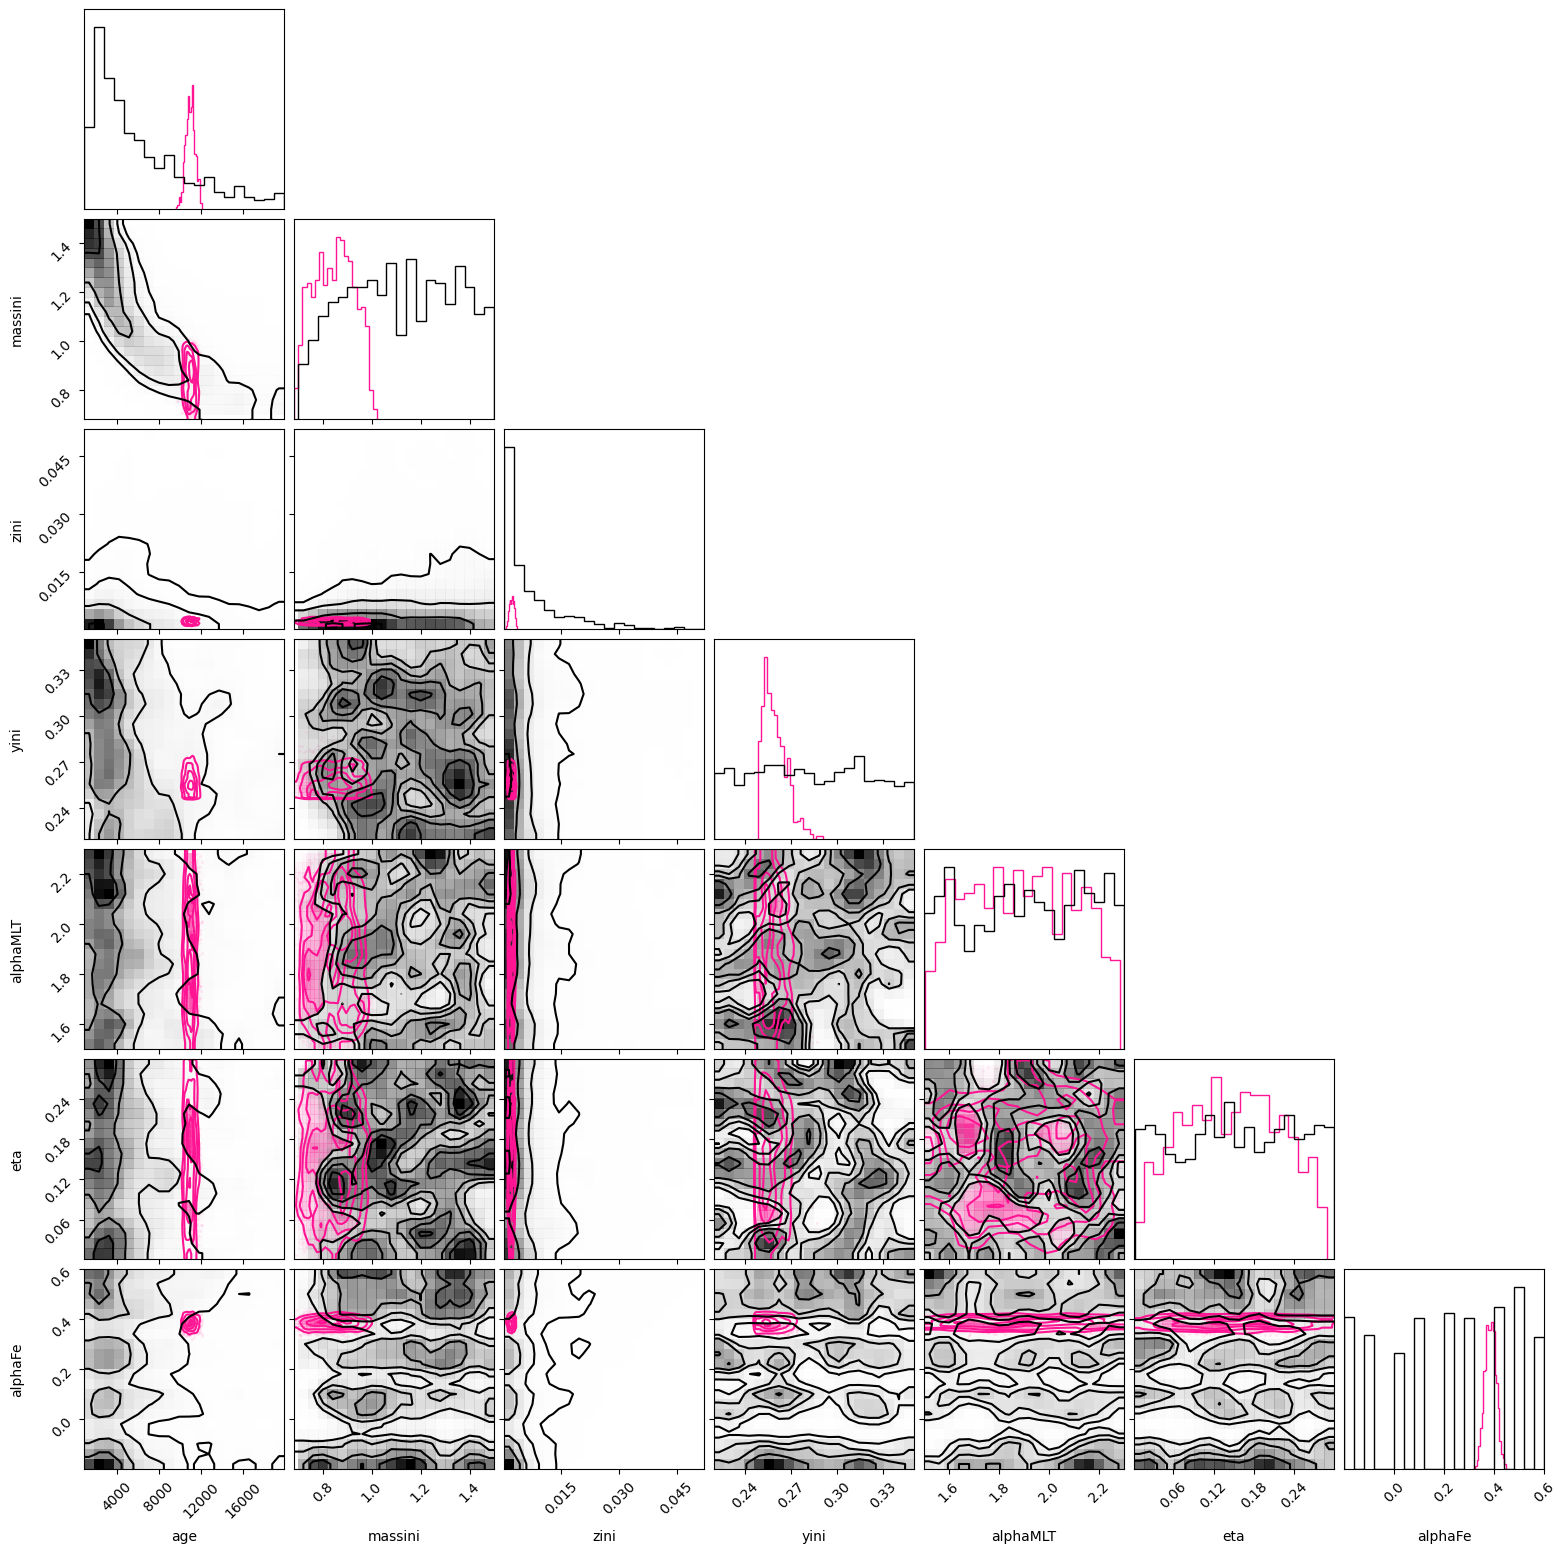

In [107]:
fig = corner.corner(data, group="prior", var_names = ['age', 'massini','zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'deeppink', smooth = True, plot_datapoints = True,  weights = np.ones(num_prior_samples)/(num_prior_samples), zorder = 100, coords = {'star':1})
corner.corner(df_small[['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']],zorder = 0, alpha = 0.1, fig = fig, smooth = True, weights = np.ones_like(df_small['massini'])/len(df_small), plot_datapoints = False,)
plt.show()

# Run the sampler

In [108]:
mcmc.run(jax.random.PRNGKey(0),  uncs=unc, obs=obs)

mcmc.print_summary()

sample: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 8000/8000 [41:15<00:00,  3.23it/s, 319 steps of size 1.01e-03. acc. prob=0.93]


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
       age_beta      0.40      0.09      0.40      0.25      0.56    187.84      1.00
   alphaFe_beta      0.48      0.14      0.48      0.26      0.71    119.76      1.01
  alphaMLT_beta      0.18      0.03      0.18      0.12      0.24    112.86      1.01
       eta_beta      0.52      0.21      0.53      0.16      0.86    162.88      1.00
    tau_beta[0]      0.58      0.02      0.58      0.54      0.61      8.86      1.00
    tau_beta[1]      0.58      0.02      0.58      0.54      0.60      8.86      1.00
    tau_beta[2]      0.57      0.02      0.58      0.54      0.60      8.87      1.00
    tau_beta[3]      0.58      0.02      0.58      0.54      0.61      8.87      1.00
    tau_beta[4]      0.58      0.02      0.58      0.54      0.60      8.87      1.00
    tau_beta[5]      0.58      0.02      0.58      0.54      0.61      8.86      1.00
    tau_beta[6]      0.58      0.02      0.58      0.

# Investigate the posterior 

In [115]:
posterior = mcmc.get_samples(group_by_chain=True)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

rng, key = jax.random.split(jax.random.PRNGKey(0))

posterior_predictive = Predictive(shared_2param, posterior_samples=posterior, parallel=True, batch_ndims=2)

post_obs = posterior_predictive(rng_key, uncs = unc)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

data += az.from_dict(posterior, sample_stats=sample_stats, coords=coords, dims=dims, )

az.to_json(data, f'../inference-objects/dnufit/pooled-model/warmup-{num_warmup}-samples-{num_samples}-{imin}-{imax}-no-numax-beta-age.json')

'../inference-objects/dnufit/pooled-model/warmup-4000-samples-4000-0-25-no-numax-beta-age.json'

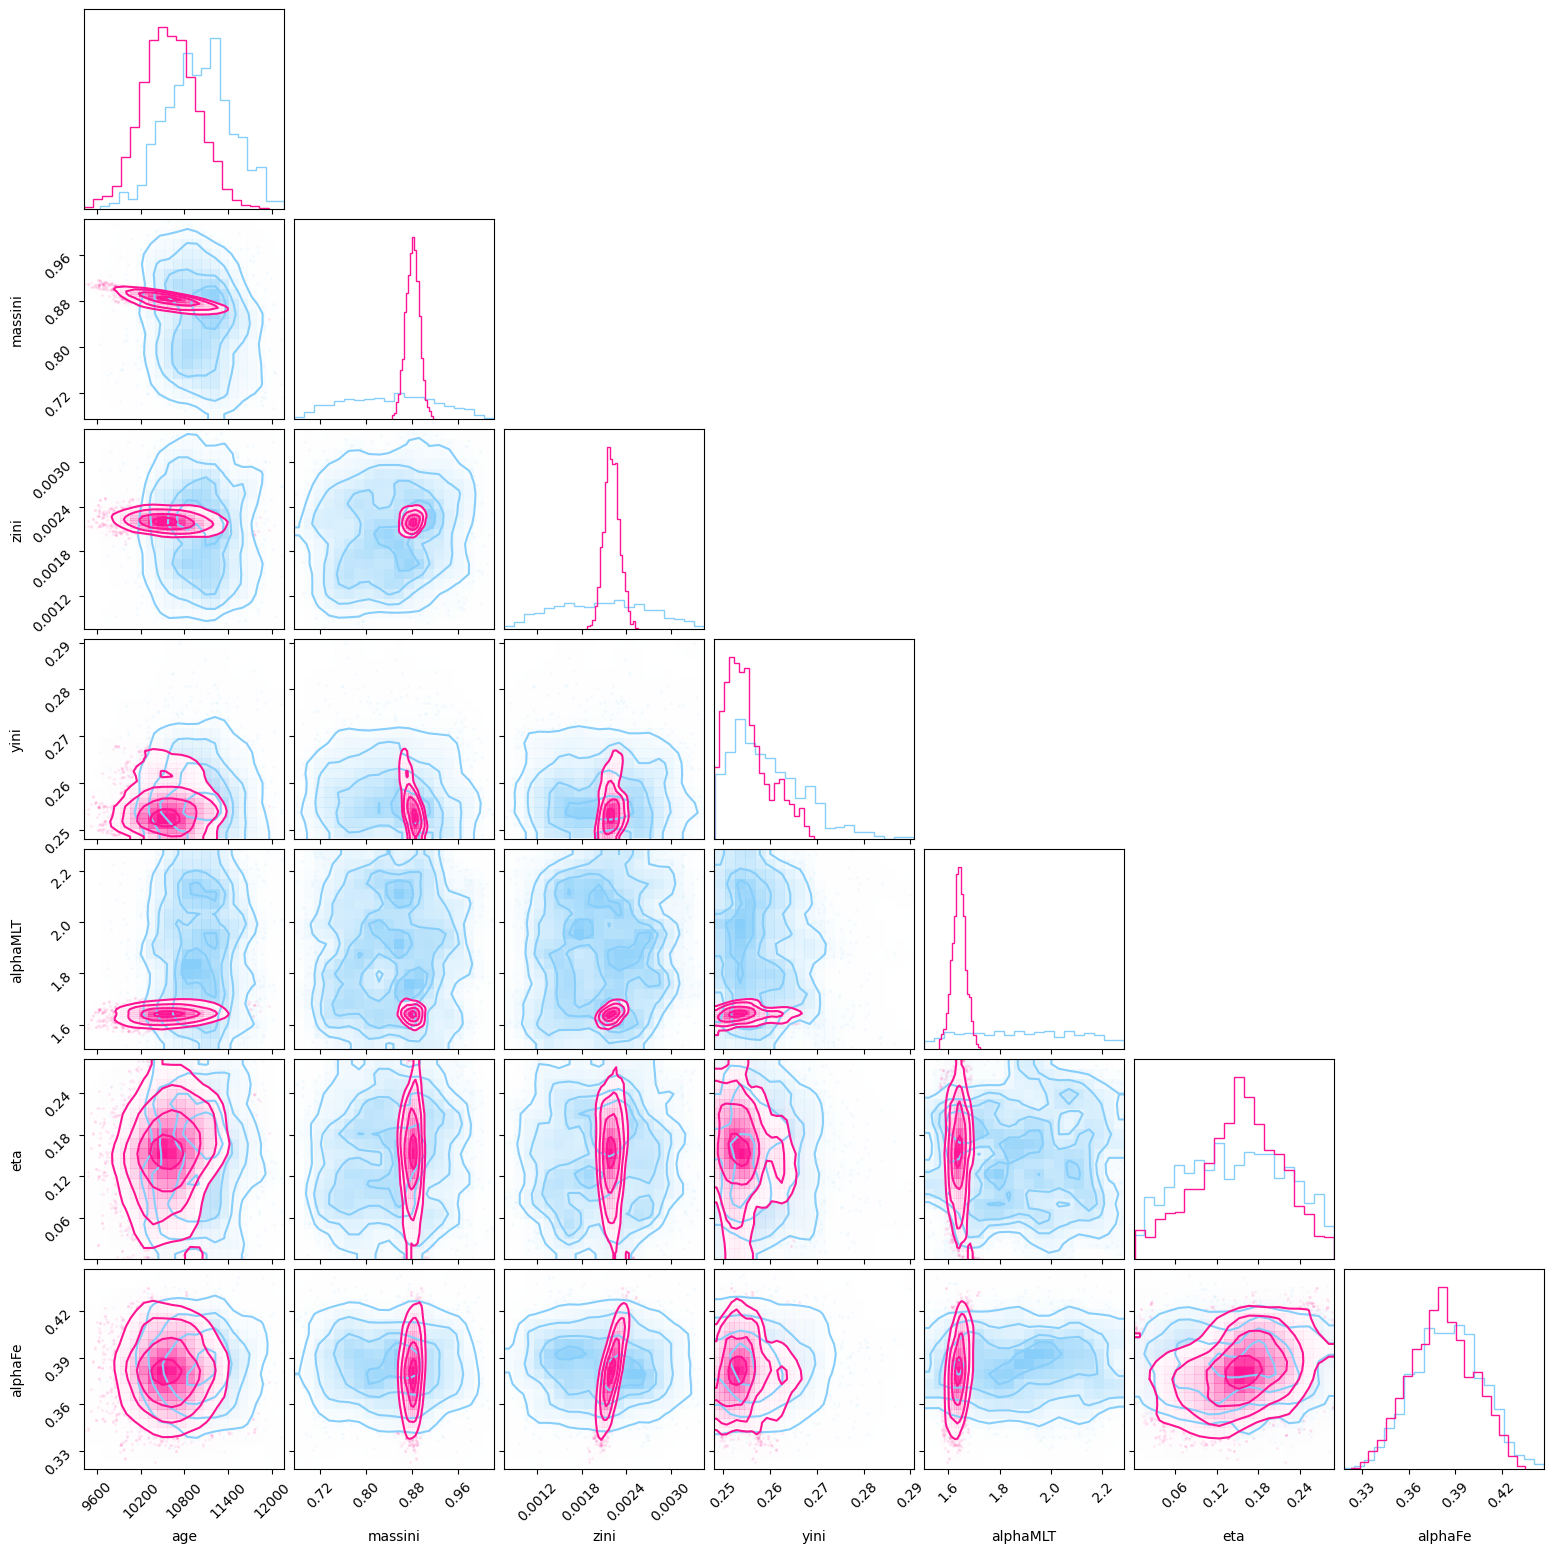

In [116]:
fig = corner.corner(data, group="prior", var_names = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'lightskyblue', smooth = True, plot_datapoints = True, hist_kwargs={'density':True}, coords = {'star':2}, )
corner.corner(data, group="posterior",  var_names = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'deeppink', zorder = 1,smooth = True, plot_datapoints = True,hist_kwargs={'density':True},coords = {'star':2}, fig = fig)
fig.savefig(f'../figs/fully-pooled-model-corner-example-star-stars-{imin}-{imax}-no-numax-beta-age.png', bbox_inches = 'tight', dpi = 150)
plt.show()


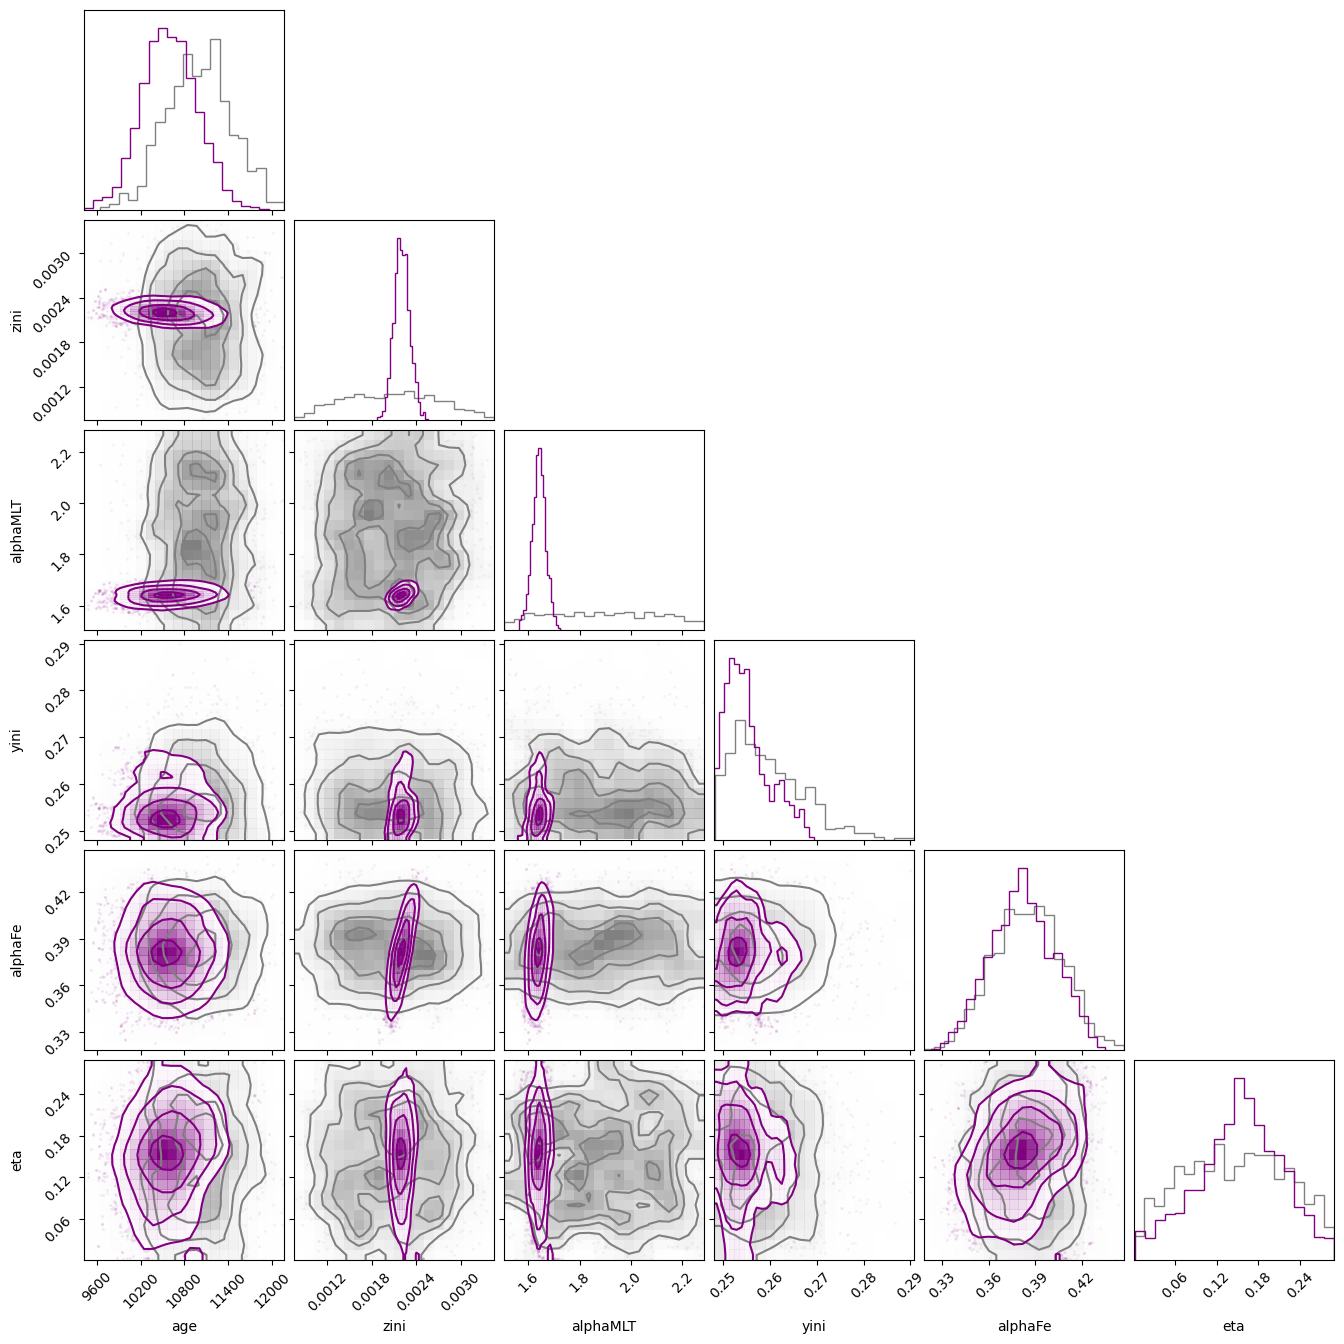

In [117]:
#hist_kwargs = {impacting synonymimpacting synonym'density':True}

fig = corner.corner(data, group="prior", var_names = ['age', 'zini', 'alphaMLT', 'yini', 'alphaFe', 'eta'], color = 'grey', smooth = True, hist_kwargs={'density':True})
corner.corner(data, group="posterior", var_names = ['age', 'zini', 'alphaMLT', 'yini', 'alphaFe', 'eta'], color = 'purple',  smooth = True, fig = fig, hist_kwargs={'density':True})
plt.savefig(f'../figs/fully-pooled-model-corner-stars-no-numax-{imin}-{imax}-beta-age.png', bbox_inches = 'tight', dpi = 150)
plt.show()


# Posterior predictive

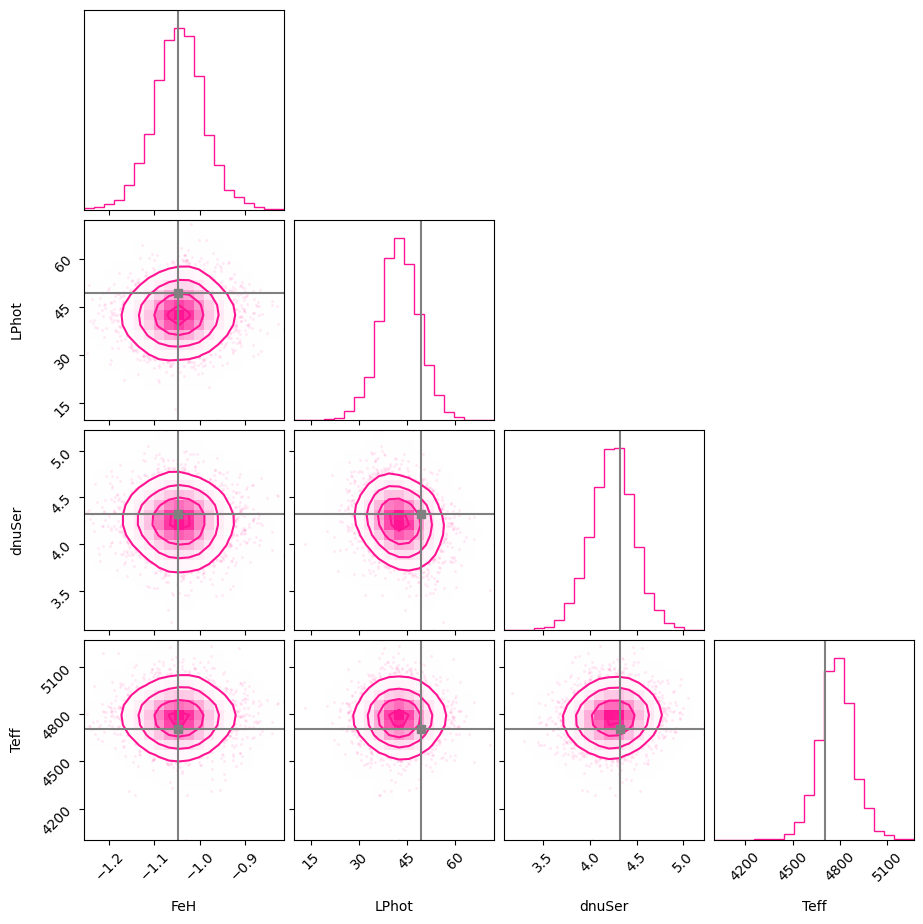

In [118]:
post_pred = az.from_dict(post_obs, coords=coords, dims=dims,)
star = 23
fig = corner.corner(post_pred, group = "posterior", var_names = ['FeH', 'LPhot', 'dnuSer', 'Teff'],  color = 'deeppink', smooth = True, plot_datapoints = True, hist_kwargs={'density':True}, coords = {'star':star}, truths = [FeH.values[star], LPhot.values[star], dnu.values[star], Teff.values[star]], truth_color = 'grey')

In [120]:
np.mean(posterior['age']), np.std(posterior['age'])

(Array(10596.0132411, dtype=float64), Array(378.95838362, dtype=float64))

(array([477., 806., 815., 680., 378., 223., 276., 177., 128.,  40.]),
 array([0.24803607, 0.25017976, 0.25232346, 0.25446715, 0.25661084,
        0.25875453, 0.26089822, 0.26304191, 0.26518561, 0.2673293 ,
        0.26947299]),
 <BarContainer object of 10 artists>)

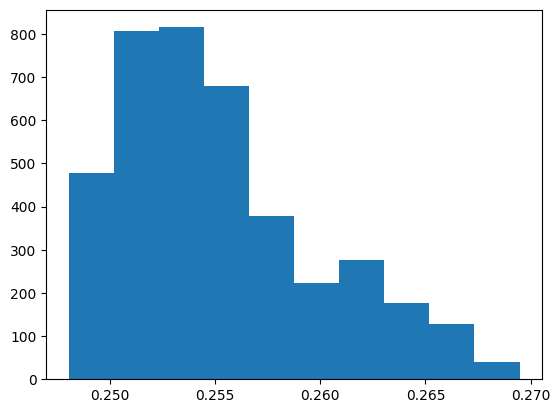

In [125]:
plt.hist(posterior['yini'][0])

In [124]:
posterior['yini']

Array([[0.25895889, 0.25894828, 0.25944251, ..., 0.25043194, 0.25065546,
        0.25065012]], dtype=float64)